In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Homework: Pressure dependence of the heat capacity of ethane (package version)

The real-substance heat capacity depends on pressure (or molar volume). Here we compute the constant-pressure heat capacity of ethane at several pressures.

> **Package version.** This notebook uses the shared `thermo` package (`PengRobinson`) instead of re-deriving the Peng–Robinson EOS inline. Compare with the self-contained companion [`PR_heat_capacity_C2H6_homework.ipynb`](PR_heat_capacity_C2H6_homework.ipynb), which builds every routine from scratch.
>
> Critical constants ($T_c$, $P_c$), the acentric factor $\omega$, and the ideal-gas $C_p$ coefficients are read from `code/data/pure_property.csv` via `PengRobinson.from_database`, so the numbers can differ slightly from the hand-entered SIS Table 6.6-1 values in the self-contained notebook.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

## Problem statement

Plot the constant-pressure heat capacity of ethane between $30^\circ$C and $200^\circ$C for the pressures 0.1, 2, and 4 MPa. Compare to the ideal-gas values $C_p^*(T)$ from the Appendix A.II correlation.

We compute $C_p = (\partial\underline{H}/\partial T)_P \approx (\Delta\underline{H}/\Delta T)_P$ from a 1 K finite difference, with $\Delta\underline{H} = \Delta\underline{H}^\mathrm{IG} + [\underline{H}-\underline{H}^\mathrm{IG}]_2 - [\underline{H}-\underline{H}^\mathrm{IG}]_1$.

## The Peng-Robinson EOS, from the `thermo` package

The generalized Peng-Robinson equation of state (SIS Eq. 6.4-2) is

$$ P = \frac{RT}{\underline{V}-b} - \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)} \tag{Eq. 6.4-2}$$

with $b = 0.07780\,RT_c/P_c$ (Eq. 6.7-2), $a(T)=0.45724\,R^2T_c^2/P_c\,\alpha(T)$ (Eq. 6.7-1), $\sqrt{\alpha}=1+\kappa(1-\sqrt{T/T_c})$ (Eq. 6.7-3), and $\kappa = 0.37464 + 1.54226\omega - 0.26992\omega^2$ (Eq. 6.7-4).

All of this — building the cubic, taking its compressibility roots (SIS Table 6.4-3), and the departure functions below — is implemented in `thermo.PengRobinson`. The self-contained companion notebook codes each of these by hand; here we just call them.

The enthalpy and entropy departure functions for the PR EOS (SIS Eqs. 6.4-29, 6.4-30) are

$$[\underline{H} - \underline{H}^\mathrm{IG}] = RT(Z-1) + \frac{T\,da/dT-a}{2\sqrt2\,b}\ln\!\left[\frac{Z+(1+\sqrt2)B}{Z+(1-\sqrt2)B}\right] \tag{Eq. 6.4-29}$$

$$[\underline{S} - \underline{S}^\mathrm{IG}] = R\ln(Z-B) + \frac{da/dT}{2\sqrt2\,b}\ln\!\left[\frac{Z+(1+\sqrt2)B}{Z+(1-\sqrt2)B}\right] \tag{Eq. 6.4-30}$$

and are returned by `pr.departure_H(T, P, phase)` and `pr.departure_S(T, P, phase)` (J/mol and J/(mol·K)). The package uses the correct $R\ln(Z-B)$ in the entropy departure.

The ideal-gas heat capacity follows the Appendix A.II correlation $C_p^*(T)=A+BT+CT^2+DT^3$, so

$$\Delta\underline{H}^\mathrm{IG}=\int_{T_1}^{T_2}C_p^*\,dT = A(T_2-T_1)+\tfrac12 B(T_2^2-T_1^2)+\tfrac13 C(T_2^3-T_1^3)+\tfrac14 D(T_2^4-T_1^4).$$

The coefficients `(A, B, C, D)` are carried on the compound as `pr.cp` (already in J/(mol·K), no unit scaling needed).

In [1]:
import sys; sys.path.append("..")   # so `import thermo` works from the chapter folder
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants, optimize
from thermo import PengRobinson

R = constants.R

In [2]:
pr = PengRobinson.from_database('ethane')
print(f"{pr.name}: Tc={pr.Tc:.1f} K, Pc={pr.Pc/1e5:.2f} bar, omega={pr.omega:.3f}")

ethane: Tc=305.4 K, Pc=48.80 bar, omega=0.099


In [3]:
# Ideal-gas Cp correlation and its integrals, using the package coefficients pr.cp
def Cp_IG(pr, T):
    A, B, C, D = pr.cp
    return A + B*T + C*T**2 + D*T**3

def dH_IG(pr, T1, T2):
    A, B, C, D = pr.cp
    return (A*(T2-T1) + B*(T2**2-T1**2)/2
            + C*(T2**3-T1**3)/3 + D*(T2**4-T1**4)/4)

def dS_IG(pr, T1, T2, P1, P2):
    A, B, C, D = pr.cp
    return (A*np.log(T2/T1) + B*(T2-T1) + C*(T2**2-T1**2)/2
            + D*(T2**3-T1**3)/3 - R*np.log(P2/P1))

In [4]:
def del_H(pr, T1, T2, P1, P2):
    """Total molar enthalpy change between (T1,P1) and (T2,P2)."""
    depH1 = pr.departure_H(T1, P1, "vapor")
    depH2 = pr.departure_H(T2, P2, "vapor")
    return dH_IG(pr, T1, T2) + (depH2 - depH1)

## Compute and plot $C_p(T)$ at each pressure

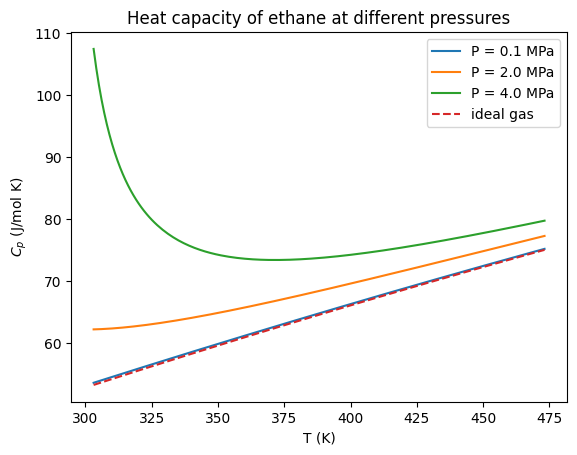

In [5]:
Ti, Tf = 30 + 273.15, 200 + 273.15
dT = 1.0    # 1 K interval for the finite-difference derivative
T = np.arange(Ti, Tf + dT, dT)

fig, ax = plt.subplots()
for P in [0.1e6, 2e6, 4e6]:
    cp = np.array([del_H(pr, T0, T0 + dT, P, P) / dT for T0 in T])
    ax.plot(T, cp, label=f"P = {P/1e6:.1f} MPa")

ax.plot(T, Cp_IG(pr, T), "--", label="ideal gas")
ax.set_xlabel("T (K)"); ax.set_ylabel("$C_p$ (J/mol K)")
ax.set_title("Heat capacity of ethane at different pressures")
ax.legend(); plt.show()

As the pressure rises, $C_p$ climbs above the ideal-gas curve and grows more temperature-dependent; the 4 MPa isobar (below $P_c$) approaches the VLE curve, where $C_p$ diverges. At high temperature each isobar relaxes back toward the ideal-gas value.